#Upload Required Dataset

In [ ]:
from google.colab import files
import os

print("Step 1: Upload prepared_data (1).csv")
files.upload()

print("Step 2: Upload archive (3).zip")
files.upload()

print("Step 3: Upload ABIDEII_MRI_Quality_Metrics (1) (1).zip")
files.upload()

print("All files uploaded ✓")


Step 1: Upload prepared_data (1).csv


Saving prepared_data (1).csv to prepared_data (1).csv
Step 2: Upload archive (3).zip


Saving archive (3).zip to archive (3).zip
Step 3: Upload ABIDEII_MRI_Quality_Metrics (1) (1).zip


Saving ABIDEII_MRI_Quality_Metrics (1) (1).zip to ABIDEII_MRI_Quality_Metrics (1) (1).zip
All files uploaded ✓


In [ ]:
!pip install shap nibabel -q
print("Packages ready ✓")

Packages ready ✓


In [ ]:
import os, zipfile
from pathlib import Path

OUT = Path("/content/outputs")
OUT.mkdir(exist_ok=True)

# Extract MRI images
with zipfile.ZipFile("/content/archive (3).zip") as z:
    z.extractall("/content/data/")

# Extract ABIDE QAP metrics
with zipfile.ZipFile("/content/ABIDEII_MRI_Quality_Metrics (1) (1).zip") as z:
    z.extractall("/content/data/")

print("Autism MRI images:",
      len(list(Path("/content/data/dataset/Autism").glob("*.png"))))
print("Non-Autism MRI images:",
      len(list(Path("/content/data/dataset/No_Autism").glob("*.png"))))
print("Outputs folder:", OUT)
print("Setup complete ✓")

Autism MRI images: 100
Non-Autism MRI images: 101
Outputs folder: /content/outputs
Setup complete ✓


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle, time
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score
)
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC
from sklearn.naive_bayes     import GaussianNB
from sklearn.neural_network  import MLPClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier,
    ExtraTreesClassifier, VotingClassifier, StackingClassifier
)
from sklearn.decomposition   import PCA
from sklearn.inspection      import permutation_importance
from PIL import Image

# Constants
OUT  = Path("/content/outputs")
SEED = 42
np.random.seed(SEED)

PALETTE = ['#2E86AB','#A23B72','#F18F01','#C73E1D',
           '#3B1F2B','#44BBA4','#E94F37','#7B2D8B']
print("All libraries imported ✓")

All libraries imported ✓


Dataset shape: (141, 26)
Label distribution:
label
0    21
1    70
2    50
Name: count, dtype: int64

Missing values per column:
age_months                               37
pregnancy_problems                       39
normally_evolved_perinatal_phenomena     39
birth_anomalies                          47
QS                                       43
IQ                                      109
QA_VABS                                   4
ADOS                                      5
I_intellective_impairment               118
II_language_impairment                   46
III_known_medical_condition              56
III_history_environmental_exposure       54
III_known_genetic_condition              54
IV_other_mental_behavioral_disorders     55
other_psychiatric_comorbidities          70
nutrition_disorders                      17
CGH_array_alterations                    45
DQ                                       71
DQ_IQ                                    39
n_alterated_chromosomes            

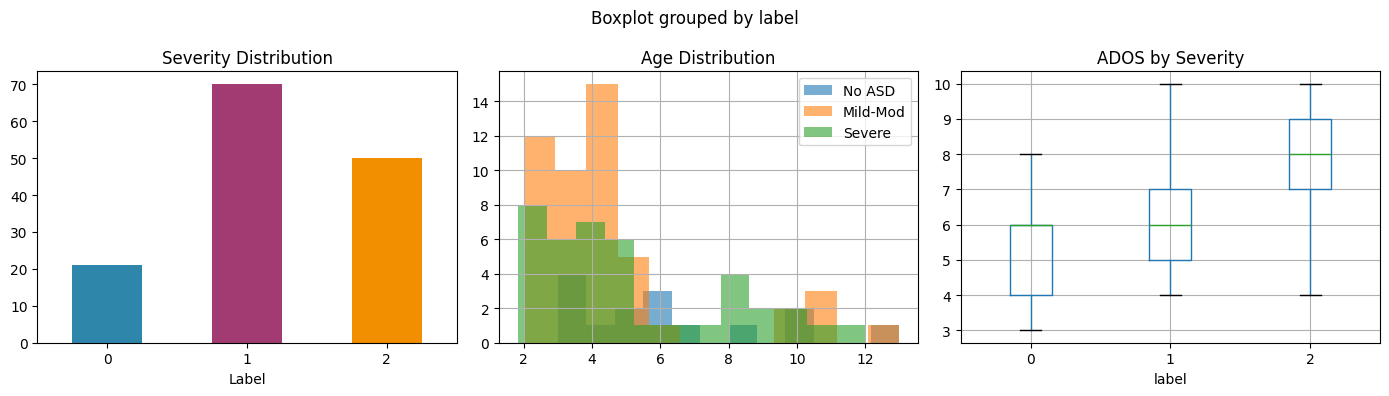

Preprocessing done ✓


In [ ]:
df = pd.read_csv("/content/prepared_data (1).csv")
print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts().sort_index()}")
print(f"\nMissing values per column:\n{df.isnull().sum()[df.isnull().sum()>0]}")

TARGET   = 'label'
FEATURES = [c for c in df.columns if c != TARGET]

X_raw      = df[FEATURES]
y_severity = df[TARGET]
y_binary   = (y_severity > 0).astype(int)

imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_imp   = imputer.fit_transform(X_raw)
X       = pd.DataFrame(scaler.fit_transform(X_imp), columns=FEATURES)

# Train / test splits
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X, y_severity, test_size=0.2, random_state=SEED, stratify=y_severity)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X, y_binary,   test_size=0.2, random_state=SEED, stratify=y_binary)

print(f"\nTrain: {len(X_tr_s)}  |  Test: {len(X_te_s)}")

# Quick EDA plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color=PALETTE[:3], rot=0)
axes[0].set_title("Severity Distribution")
axes[0].set_xlabel("Label")

for lbl, name in zip([0,1,2], ['No ASD','Mild-Mod','Severe']):
    df[df['label']==lbl]['age_months'].dropna().div(12).hist(
        ax=axes[1], bins=12, alpha=0.6, label=name)
axes[1].set_title("Age Distribution")
axes[1].legend()

df.boxplot(column='ADOS', by='label', ax=axes[2])
axes[2].set_title("ADOS by Severity")
plt.tight_layout()
plt.savefig(OUT/"05_eda.png", dpi=130, bbox_inches='tight')
plt.show()
print("Preprocessing done ✓")

In [ ]:
stacking = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=SEED)),
        ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=SEED)),
        ('svm', SVC(probability=True, random_state=SEED)),
    ],
    final_estimator=LogisticRegression(max_iter=1000), cv=5
)
voting = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(n_estimators=100, random_state=SEED, class_weight='balanced')),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=SEED)),
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=SEED, class_weight='balanced')),
], voting='soft')

ALL_MODELS = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    "Decision Tree":        DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=SEED),
    "K-Nearest Neighbors":  KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)":            SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=SEED),
    "Naive Bayes":          GaussianNB(),
    "MLP Neural Net":       MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, early_stopping=True, random_state=SEED),
    "Random Forest":        RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED),
    "Extra Trees":          ExtraTreesClassifier(n_estimators=200, class_weight='balanced', random_state=SEED),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, random_state=SEED),
    "AdaBoost":             AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED),
    "Bagging (DT)":         BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5), n_estimators=100, random_state=SEED),
    "Voting Ensemble":      voting,
    "Stacking Ensemble":    stacking,
}

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    tr_acc = accuracy_score(y_tr, model.predict(X_tr))
    te_acc = accuracy_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    prec   = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec    = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    cv     = cross_val_score(model, X_tr, y_tr, cv=5, scoring='f1_weighted', n_jobs=-1)
    try:
        proba = model.predict_proba(X_te)
        n_cls = len(np.unique(y_te))
        auc = roc_auc_score(y_te, proba, multi_class='ovr', average='weighted') \
              if n_cls > 2 else roc_auc_score(y_te, proba[:,1])
    except: auc = np.nan
    return dict(name=name, model=model, train_acc=tr_acc, test_acc=te_acc,
                f1=f1, precision=prec, recall=rec, auc=auc,
                cv_mean=cv.mean(), cv_std=cv.std(),
                overfit_gap=tr_acc-te_acc, train_time=time.time()-t0, y_pred=y_pred)

print("=== Severity Estimation (3-class) ===")
sev_results = []
for name, mdl in ALL_MODELS.items():
    # Re-clone to avoid state issues across tasks
    import copy
    r = evaluate(name, copy.deepcopy(mdl), X_tr_s, X_te_s, y_tr_s, y_te_s)
    sev_results.append(r)
    flag = " ⚠OVERFIT" if r['overfit_gap']>0.15 else ""
    print(f"  {name:<24} Acc={r['test_acc']:.3f} F1={r['f1']:.3f} "
          f"CV={r['cv_mean']:.3f}±{r['cv_std']:.2f} AUC={r['auc']:.3f}{flag}")

best_sev = max(sev_results, key=lambda x: x['f1'])
print(f"\n★ Best Severity: {best_sev['name']}  F1={best_sev['f1']:.3f}")

print("\n=== Binary ASD Classification ===")
bin_results = []
for name, mdl in ALL_MODELS.items():
    import copy
    r = evaluate(name, copy.deepcopy(mdl), X_tr_b, X_te_b, y_tr_b, y_te_b)
    bin_results.append(r)
    flag = " ⚠OVERFIT" if r['overfit_gap']>0.15 else ""
    print(f"  {name:<24} Acc={r['test_acc']:.3f} F1={r['f1']:.3f} "
          f"CV={r['cv_mean']:.3f}±{r['cv_std']:.2f} AUC={r['auc']:.3f}{flag}")

best_bin = max(bin_results, key=lambda x: x['f1'])
print(f"\n★ Best Binary: {best_bin['name']}  F1={best_bin['f1']:.3f}")

=== Severity Estimation (3-class) ===
  Logistic Regression      Acc=0.621 F1=0.619 CV=0.548±0.07 AUC=0.722 ⚠OVERFIT
  Decision Tree            Acc=0.517 F1=0.530 CV=0.536±0.11 AUC=0.611 ⚠OVERFIT
  K-Nearest Neighbors      Acc=0.552 F1=0.535 CV=0.559±0.03 AUC=0.638 ⚠OVERFIT
  SVM (RBF)                Acc=0.483 F1=0.487 CV=0.610±0.09 AUC=0.691 ⚠OVERFIT
  Naive Bayes              Acc=0.379 F1=0.302 CV=0.228±0.03 AUC=0.688
  MLP Neural Net           Acc=0.483 F1=0.443 CV=0.495±0.09 AUC=0.623
  Random Forest            Acc=0.655 F1=0.652 CV=0.681±0.04 AUC=0.787 ⚠OVERFIT
  Extra Trees              Acc=0.621 F1=0.616 CV=0.678±0.04 AUC=0.758 ⚠OVERFIT
  Gradient Boosting        Acc=0.690 F1=0.683 CV=0.639±0.08 AUC=0.805 ⚠OVERFIT
  AdaBoost                 Acc=0.655 F1=0.654 CV=0.599±0.06 AUC=0.788
  Bagging (DT)             Acc=0.655 F1=0.652 CV=0.661±0.05 AUC=0.813 ⚠OVERFIT
  Voting Ensemble          Acc=0.655 F1=0.652 CV=0.663±0.04 AUC=0.791 ⚠OVERFIT
  Stacking Ensemble        Acc=0.655 F1=0

In [ ]:
param_grids = {
    "Random Forest": {
        'n_estimators':       [100, 200, 300],
        'max_depth':          [5, 8, 12, None],
        'min_samples_split':  [2, 5, 10],
        'class_weight':       ['balanced']
    },
    "Gradient Boosting": {
        'n_estimators':   [100, 150, 200],
        'learning_rate':  [0.01, 0.05, 0.1],
        'max_depth':      [3, 4, 5],
        'subsample':      [0.8, 1.0]
    },
    "Extra Trees": {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [5, 8, 12, None],
        'min_samples_split': [2, 5, 10],
        'class_weight':      ['balanced']
    },
    "AdaBoost": {
        'n_estimators':  [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.5]
    }
}
base_estimators = {
    "Random Forest":     RandomForestClassifier(random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "Extra Trees":       ExtraTreesClassifier(random_state=SEED),
    "AdaBoost":          AdaBoostClassifier(random_state=SEED),
}

top3_names = [r['name'] for r in sorted(sev_results, key=lambda x: x['f1'], reverse=True)
              if r['name'] in param_grids][:3]

tuned_results = []
for name in top3_names:
    print(f"\nTuning: {name}")
    gs = GridSearchCV(base_estimators[name], param_grids[name],
                      cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0)
    gs.fit(X_tr_s, y_tr_s)

    y_pred_t = gs.best_estimator_.predict(X_te_s)
    t_f1  = f1_score(y_te_s, y_pred_t, average='weighted')
    t_acc = accuracy_score(y_te_s, y_pred_t)
    orig  = next(r['f1'] for r in sev_results if r['name']==name)

    print(f"  Before: F1={orig:.3f} | After: F1={t_f1:.3f} | "
          f"Improvement: {t_f1-orig:+.3f}")
    print(f"  Best params: {gs.best_params_}")
    tuned_results.append(dict(name=name, model=gs.best_estimator_,
                               f1=t_f1, acc=t_acc, orig_f1=orig,
                               best_params=gs.best_params_, y_pred=y_pred_t))

best_tuned = max(tuned_results, key=lambda x: x['f1'])
print(f"\n★ Best tuned model: {best_tuned['name']}  F1={best_tuned['f1']:.3f}")


Tuning: Gradient Boosting
  Before: F1=0.683 | After: F1=0.722 | Improvement: +0.039
  Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

Tuning: AdaBoost
  Before: F1=0.654 | After: F1=0.716 | Improvement: +0.062
  Best params: {'learning_rate': 0.5, 'n_estimators': 100}

Tuning: Random Forest
  Before: F1=0.652 | After: F1=0.652 | Improvement: +0.000
  Best params: {'class_weight': 'balanced', 'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 300}

★ Best tuned model: Gradient Boosting  F1=0.722


<Figure size 1000x700 with 0 Axes>

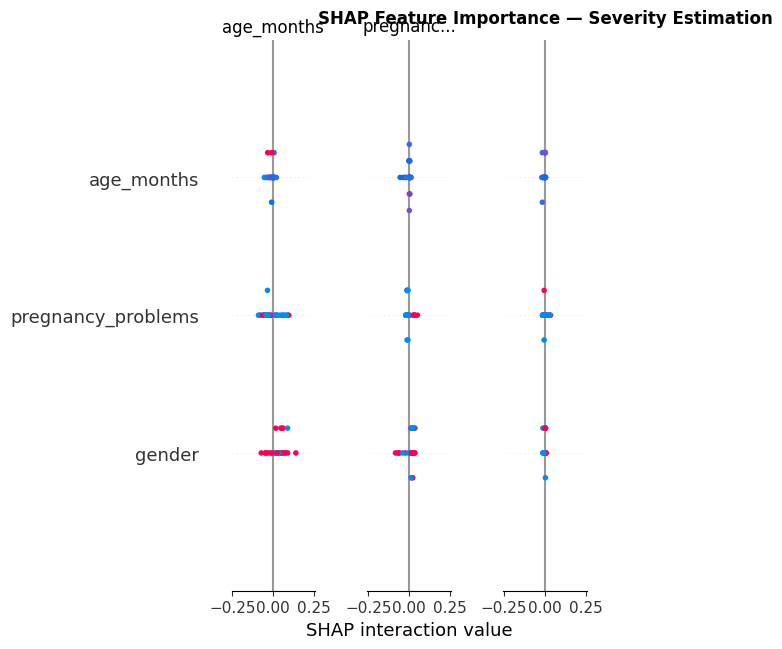

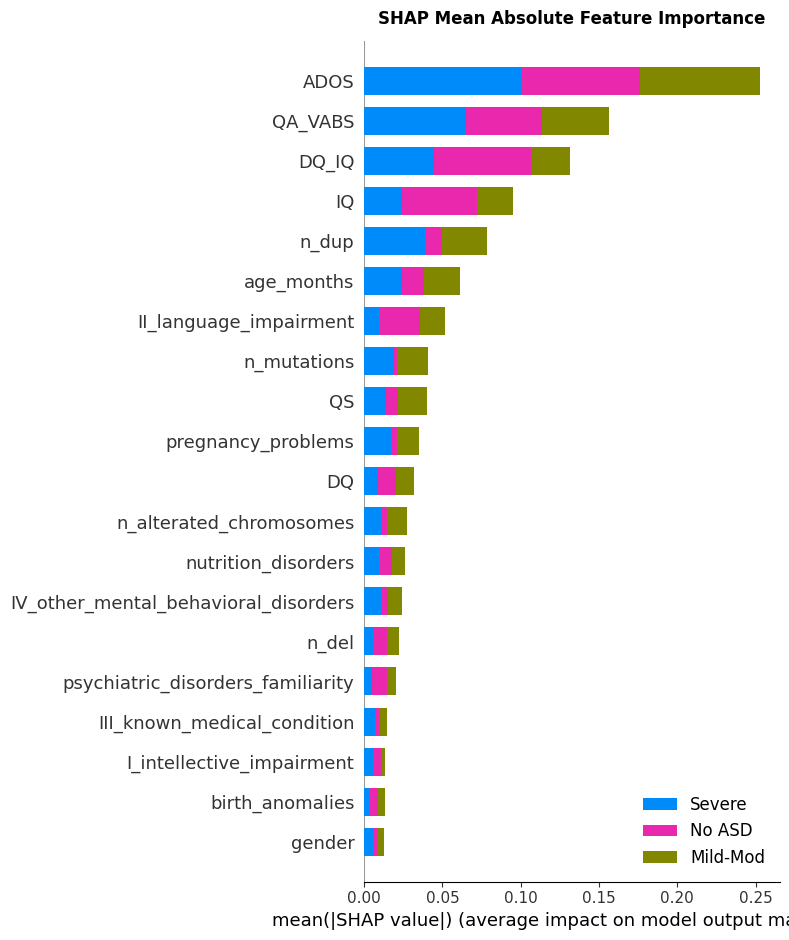

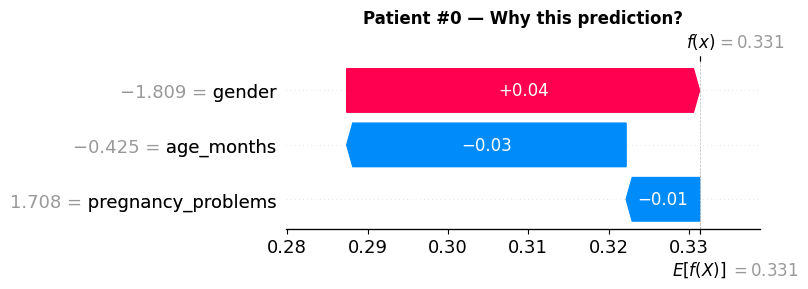

SHAP plots saved ✓


In [ ]:
# SHAP works best with RandomForest for multi-class
# Use best random forest model for explanation
rf_for_shap = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight='balanced', random_state=SEED
)
rf_for_shap.fit(X_tr_s, y_tr_s)

explainer   = shap.TreeExplainer(rf_for_shap)
shap_values = explainer.shap_values(X_te_s)

# ── Plot 1: Summary dot plot ──────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_te_s, feature_names=FEATURES,
                  class_names=['No ASD', 'Mild-Mod', 'Severe'],
                  show=False)
plt.title("SHAP Feature Importance — Severity Estimation",
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(OUT/"08_shap_summary.png", dpi=130, bbox_inches='tight')
plt.show()

# ── Plot 2: Bar importance (mean |SHAP|) ─────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_te_s, feature_names=FEATURES,
                  plot_type='bar',
                  class_names=['No ASD', 'Mild-Mod', 'Severe'],
                  show=False)
plt.title("SHAP Mean Absolute Feature Importance",
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(OUT/"09_shap_bar.png", dpi=130, bbox_inches='tight')
plt.show()

# ── Plot 3: Waterfall for individual patient ──────────────────────────
# Class 1 = Mild-Moderate ASD explanation
shap_class1 = shap_values[1]
patient_idx  = 0

exp = shap.Explanation(
    values        = shap_class1[patient_idx],
    base_values   = explainer.expected_value[1],
    data          = X_te_s.iloc[patient_idx].values,
    feature_names = FEATURES
)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(exp, max_display=12, show=False)
plt.title(f"Patient #{patient_idx} — Why this prediction?",
          fontweight='bold')
plt.tight_layout()
plt.savefig(OUT/"10_shap_waterfall.png", dpi=130, bbox_inches='tight')
plt.show()

print("SHAP plots saved ✓")

In [ ]:
IMG_SIZE = (64, 64)
DATA_DIR = Path("/content/data/dataset")

images, img_labels = [], []
for cls_name, cls_label in [("Autism", 1), ("No_Autism", 0)]:
    for img_path in sorted((DATA_DIR/cls_name).glob("*.png")):
        img = Image.open(img_path).convert('L').resize(IMG_SIZE, Image.LANCZOS)
        images.append(np.array(img, dtype=np.float32).flatten() / 255.0)
        img_labels.append(cls_label)

X_img = np.array(images)
y_img = np.array(img_labels)
print(f"Loaded {len(X_img)} images: ASD={y_img.sum()}  Non-ASD={(y_img==0).sum()}")

# PCA feature extraction
scaler_img = StandardScaler()
X_sc = scaler_img.fit_transform(X_img)
pca = PCA(n_components=80, random_state=SEED)
X_pca = pca.fit_transform(X_sc)
print(f"PCA 80 components explain {pca.explained_variance_ratio_.sum()*100:.1f}% variance")

# Statistical features per image
def stat_features(flat):
    img2d = flat.reshape(IMG_SIZE)
    feats = [img2d.mean(), img2d.std(),
             np.percentile(img2d,25), np.percentile(img2d,75)]
    h,w = IMG_SIZE
    for r1,r2,c1,c2 in [(0,h//2,0,w//2),(0,h//2,w//2,w),
                         (h//2,h,0,w//2),(h//2,h,w//2,w)]:
        q = img2d[r1:r2,c1:c2]; feats += [q.mean(), q.std()]
    hist,_ = np.histogram(img2d, bins=8, range=(0,1), density=True)
    return np.array(feats + hist.tolist())

X_stat = np.vstack([stat_features(x) for x in X_img])
X_mri  = np.hstack([X_pca, X_stat])
print(f"Combined feature vector: {X_mri.shape[1]} dims")

X_mtr, X_mte, y_mtr, y_mte = train_test_split(
    X_mri, y_img, test_size=0.2, random_state=SEED, stratify=y_img)
print(f"MRI Train: {len(X_mtr)}  |  Test: {len(X_mte)}")

Loaded 201 images: ASD=100  Non-ASD=101
PCA 80 components explain 90.3% variance
Combined feature vector: 100 dims
MRI Train: 160  |  Test: 41


In [ ]:
mri_models = {
    "Random Forest":     RandomForestClassifier(n_estimators=300, max_depth=12, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, random_state=SEED),
    "Extra Trees":       ExtraTreesClassifier(n_estimators=300, max_depth=12, random_state=SEED),
    "MLP Classifier":    MLPClassifier(hidden_layer_sizes=(256,128,64), max_iter=500,
                                       early_stopping=True, random_state=SEED),
    "Voting Ensemble":   VotingClassifier(estimators=[
        ('rf', RandomForestClassifier(n_estimators=300, random_state=SEED)),
        ('gb', GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, random_state=SEED)),
        ('et', ExtraTreesClassifier(n_estimators=300, random_state=SEED)),
    ], voting='soft'),
}

mri_results = []
print("=== MRI Image Classification ===")
for name, mdl in mri_models.items():
    mdl.fit(X_mtr, y_mtr)
    y_pred = mdl.predict(X_mte)
    acc = accuracy_score(y_mte, y_pred)
    f1  = f1_score(y_mte, y_pred, average='weighted')
    auc = roc_auc_score(y_mte, mdl.predict_proba(X_mte)[:,1])
    cv  = cross_val_score(mdl, X_mtr, y_mtr, cv=5, scoring='accuracy').mean()
    mri_results.append(dict(name=name, model=mdl, acc=acc, f1=f1, auc=auc, cv=cv, y_pred=y_pred))
    print(f"  {name:<22} Acc={acc:.3f} F1={f1:.3f} AUC={auc:.3f} CV={cv:.3f}")

best_mri = max(mri_results, key=lambda x: x['f1'])
print(f"\n★ Best MRI model: {best_mri['name']}  F1={best_mri['f1']:.3f}")
print("\nDetailed report:")
print(classification_report(y_mte, best_mri['y_pred'],
      target_names=['Non-Autism','Autism']))

=== MRI Image Classification ===
  Random Forest          Acc=0.756 F1=0.756 AUC=0.856 CV=0.850
  Gradient Boosting      Acc=0.805 F1=0.805 AUC=0.852 CV=0.819
  Extra Trees            Acc=0.805 F1=0.805 AUC=0.881 CV=0.844
  MLP Classifier         Acc=0.780 F1=0.780 AUC=0.902 CV=0.750
  Voting Ensemble        Acc=0.829 F1=0.829 AUC=0.886 CV=0.831

★ Best MRI model: Voting Ensemble  F1=0.829

Detailed report:
              precision    recall  f1-score   support

  Non-Autism       0.85      0.81      0.83        21
      Autism       0.81      0.85      0.83        20

    accuracy                           0.83        41
   macro avg       0.83      0.83      0.83        41
weighted avg       0.83      0.83      0.83        41



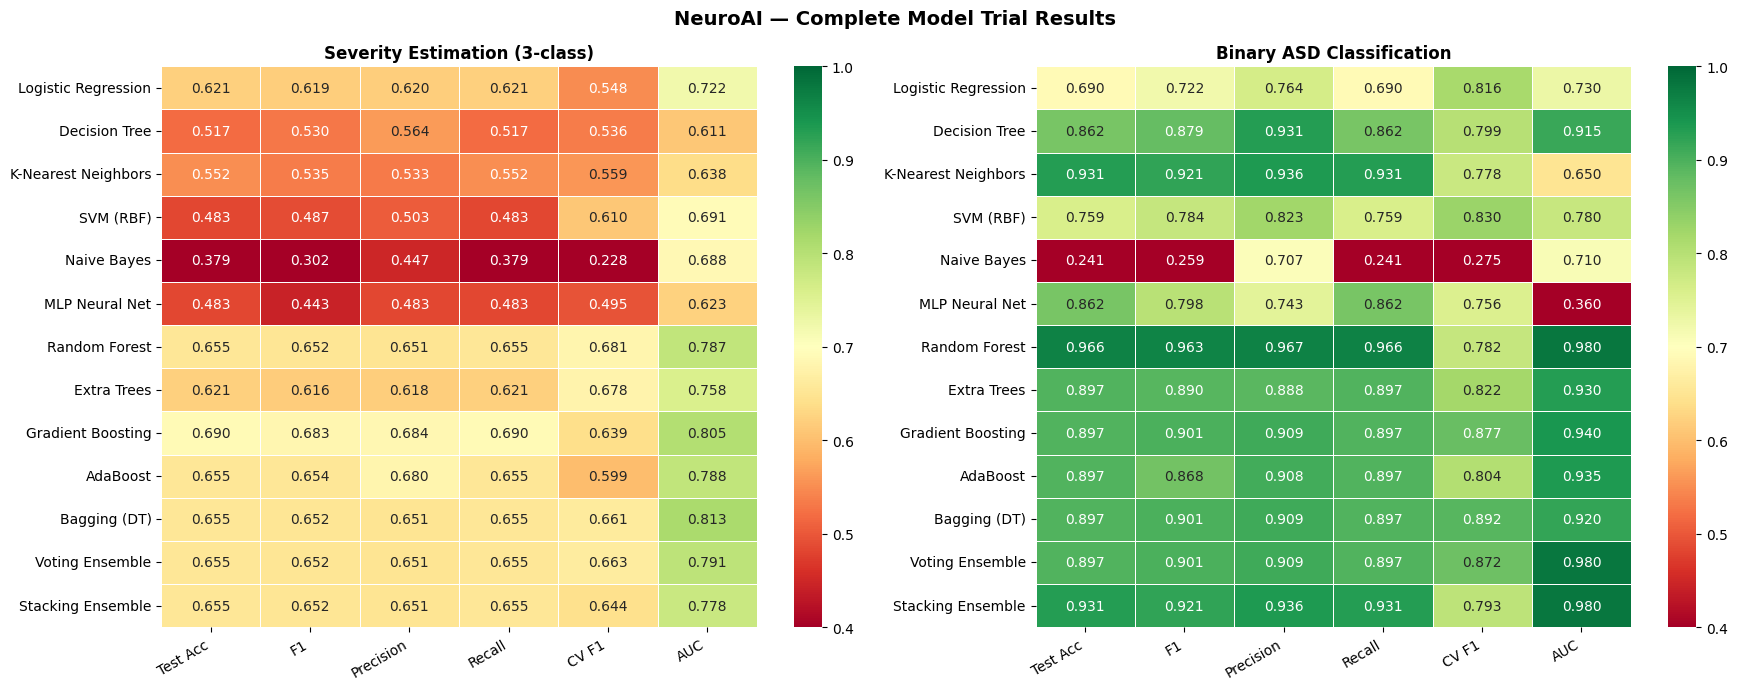

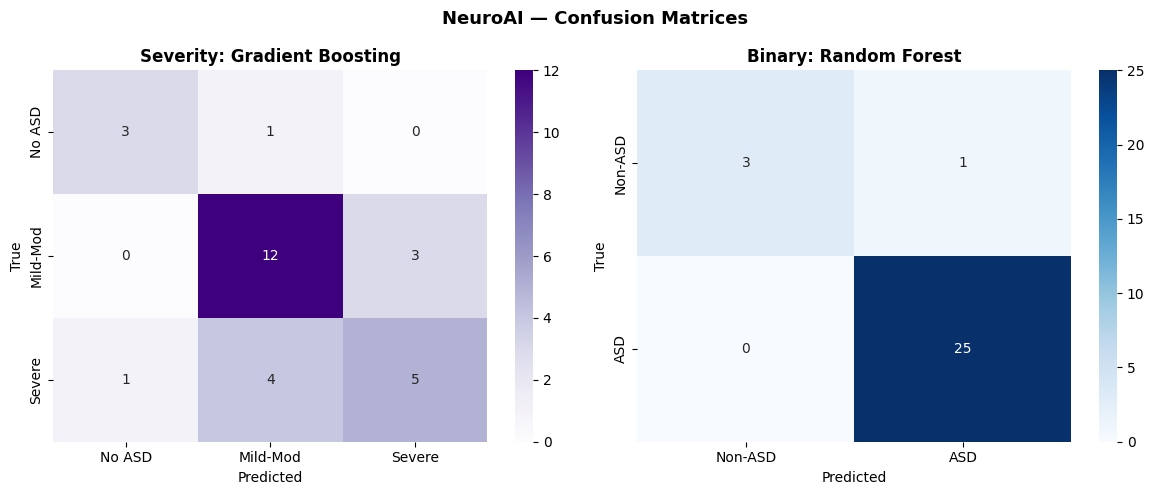

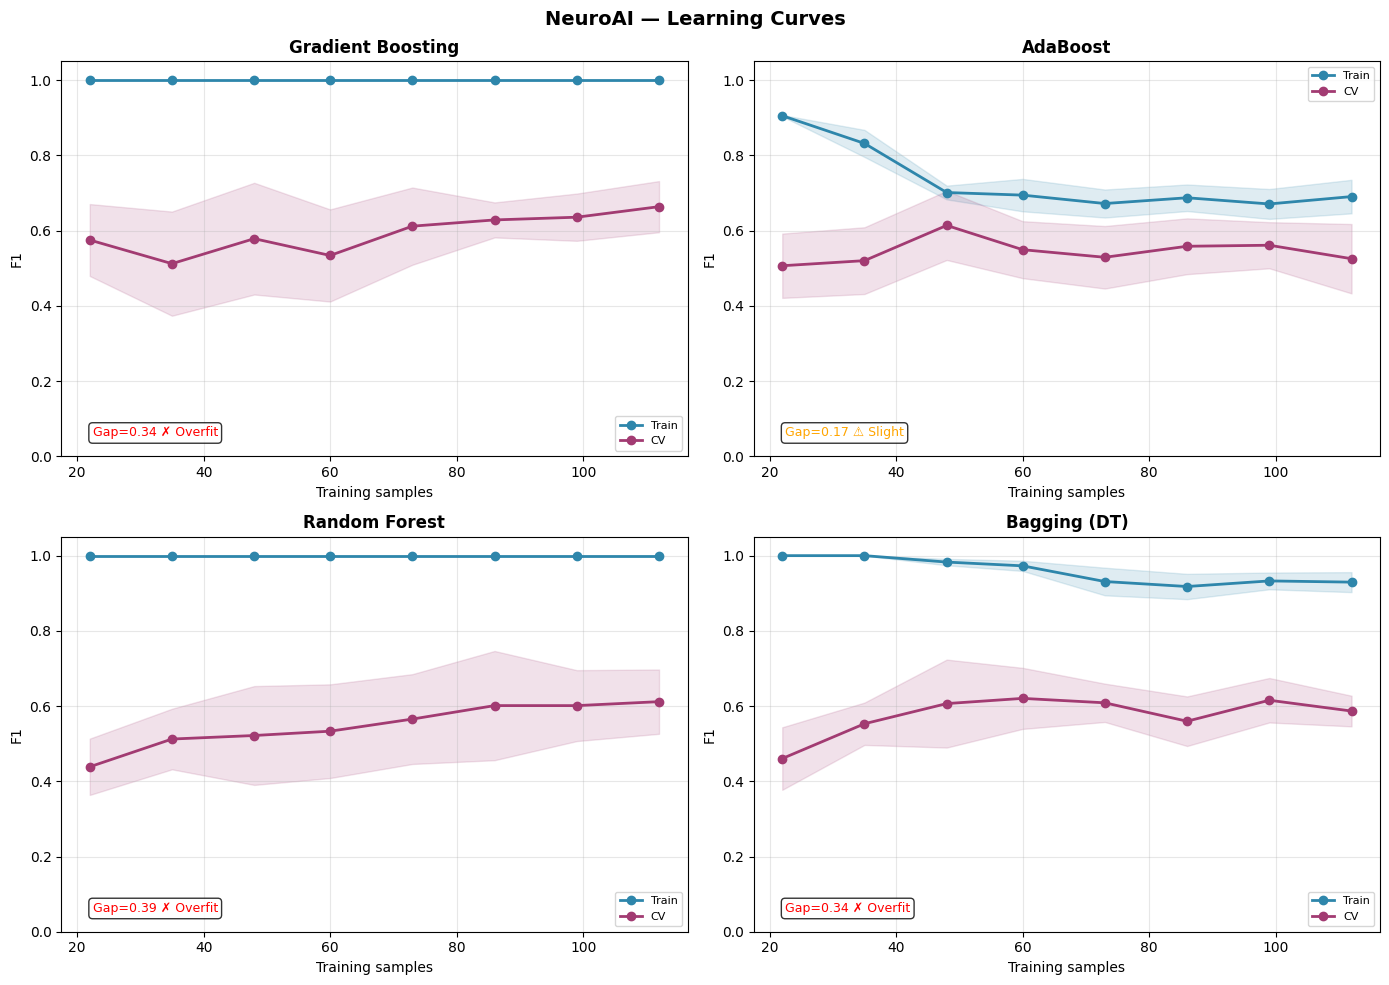

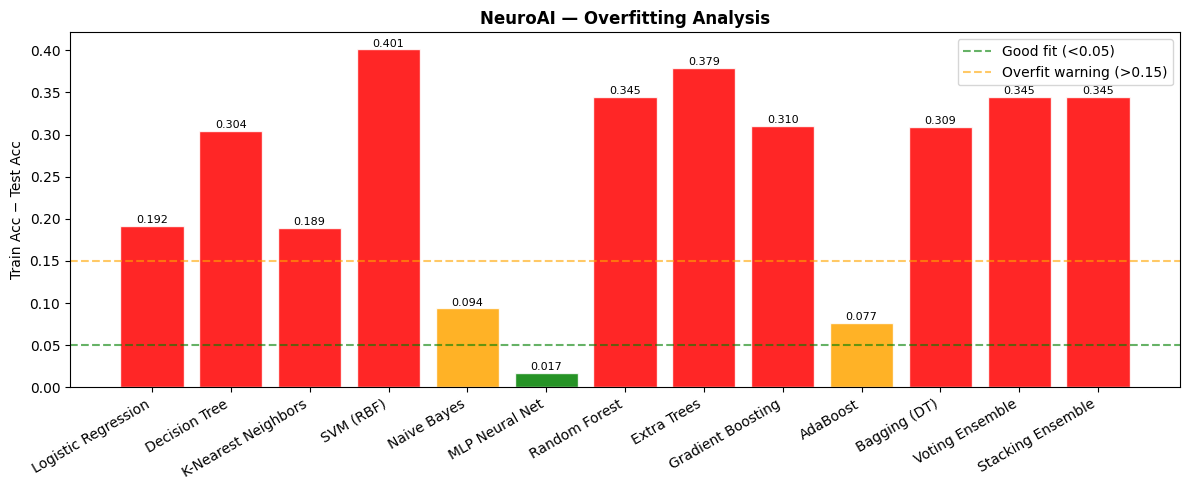

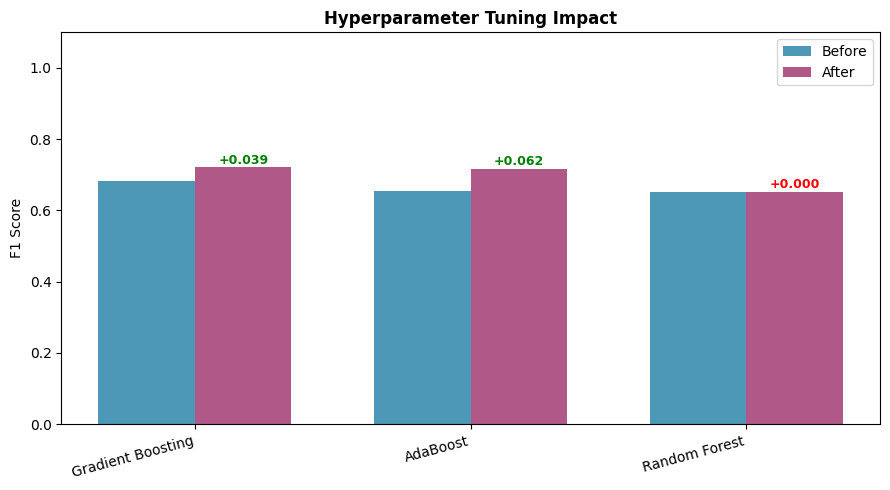

All plots saved ✓


In [ ]:
## ── 1. Model heatmap ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("NeuroAI — Complete Model Trial Results", fontsize=14, fontweight='bold')

def make_heatmap(ax, results, title):
    metrics = ['test_acc','f1','precision','recall','cv_mean','auc']
    labels  = ['Test Acc','F1','Precision','Recall','CV F1','AUC']
    names   = [r['name'] for r in results]
    data    = np.array([[r.get(m, np.nan) for m in metrics] for r in results])
    df_h    = pd.DataFrame(data, index=names, columns=labels)
    sns.heatmap(df_h, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
                vmin=0.4, vmax=1.0, linewidths=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

make_heatmap(axes[0], sev_results, "Severity Estimation (3-class)")
make_heatmap(axes[1], bin_results, "Binary ASD Classification")
plt.tight_layout()
plt.savefig(OUT/"11_model_heatmap.png", dpi=130, bbox_inches='tight')
plt.show()

## ── 2. Confusion matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("NeuroAI — Confusion Matrices", fontsize=13, fontweight='bold')
cm_s = confusion_matrix(y_te_s, best_sev['y_pred'])
cm_b = confusion_matrix(y_te_b, best_bin['y_pred'])
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['No ASD','Mild-Mod','Severe'],
            yticklabels=['No ASD','Mild-Mod','Severe'])
axes[0].set_title(f"Severity: {best_sev['name']}", fontweight='bold')
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Non-ASD','ASD'],
            yticklabels=['Non-ASD','ASD'])
axes[1].set_title(f"Binary: {best_bin['name']}", fontweight='bold')
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(OUT/"12_confusion_matrices.png", dpi=130, bbox_inches='tight')
plt.show()

## ── 3. Learning curves (top 4 models) ───────────────────────────────────
top4 = sorted(sev_results, key=lambda x: x['f1'], reverse=True)[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("NeuroAI — Learning Curves", fontsize=14, fontweight='bold')
for i, r in enumerate(top4):
    ax = axes[i//2][i%2]
    ts, tr_sc, va_sc = learning_curve(r['model'], X, y_severity, cv=5,
        scoring='f1_weighted', train_sizes=np.linspace(0.2,1.0,8), n_jobs=-1)
    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    va_m, va_s = va_sc.mean(1), va_sc.std(1)
    ax.plot(ts, tr_m, 'o-', color=PALETTE[0], label='Train', lw=2)
    ax.fill_between(ts, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color=PALETTE[0])
    ax.plot(ts, va_m, 'o-', color=PALETTE[1], label='CV', lw=2)
    ax.fill_between(ts, va_m-va_s, va_m+va_s, alpha=0.15, color=PALETTE[1])
    gap = tr_m[-1] - va_m[-1]
    status = "✓ Good" if gap<0.1 else ("⚠ Slight" if gap<0.2 else "✗ Overfit")
    ax.text(0.05, 0.05, f"Gap={gap:.2f} {status}", transform=ax.transAxes,
            fontsize=9, color='green' if gap<0.1 else 'orange' if gap<0.2 else 'red',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_title(r['name'], fontweight='bold'); ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
    ax.set_xlabel("Training samples"); ax.set_ylabel("F1")
plt.tight_layout()
plt.savefig(OUT/"13_learning_curves.png", dpi=130, bbox_inches='tight')
plt.show()

## ── 4. Overfitting bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
names = [r['name'] for r in sev_results]
gaps  = [r['overfit_gap'] for r in sev_results]
colors = ['green' if g<0.05 else 'orange' if g<0.15 else 'red' for g in gaps]
bars = ax.bar(names, gaps, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(0.05, color='green',  ls='--', alpha=0.6, label='Good fit (<0.05)')
ax.axhline(0.15, color='orange', ls='--', alpha=0.6, label='Overfit warning (>0.15)')
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel("Train Acc − Test Acc"); ax.legend()
ax.set_title("NeuroAI — Overfitting Analysis", fontweight='bold')
for b, g in zip(bars, gaps):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{g:.3f}',
            ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUT/"14_overfitting.png", dpi=130, bbox_inches='tight')
plt.show()

## ── 5. Before vs after tuning ────────────────────────────────────────────
if tuned_results:
    fig, ax = plt.subplots(figsize=(9, 5))
    tnames = [r['name'] for r in tuned_results]
    before = [r['orig_f1'] for r in tuned_results]
    after  = [r['f1']      for r in tuned_results]
    x = np.arange(len(tnames)); w = 0.35
    b1 = ax.bar(x-w/2, before, w, label='Before', color=PALETTE[0], alpha=0.85)
    b2 = ax.bar(x+w/2, after,  w, label='After',  color=PALETTE[1], alpha=0.85)
    for i,(bf,af) in enumerate(zip(before,after)):
        ax.annotate(f'{af-bf:+.3f}', xy=(x[i]+w/2, af+0.01),
                    ha='center', fontsize=9, fontweight='bold',
                    color='green' if af>bf else 'red')
    ax.set_xticks(x); ax.set_xticklabels(tnames, rotation=15, ha='right')
    ax.set_ylim(0, 1.1); ax.legend(); ax.set_ylabel("F1 Score")
    ax.set_title("Hyperparameter Tuning Impact", fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT/"15_tuning.png", dpi=130, bbox_inches='tight')
    plt.show()

print("All plots saved ✓")

In [ ]:
final_sev_model = best_tuned['model'] if tuned_results else best_sev['model']

# Save models
with open(OUT/"best_severity_model.pkl", 'wb') as f:
    pickle.dump(final_sev_model, f)
with open(OUT/"best_binary_model.pkl", 'wb') as f:
    pickle.dump(best_bin['model'], f)
with open(OUT/"best_mri_model.pkl", 'wb') as f:
    pickle.dump({'model': best_mri['model'], 'pca': pca, 'scaler': scaler_img}, f)
with open(OUT/"preprocessor.pkl", 'wb') as f:
    pickle.dump({'imputer': imputer, 'scaler': scaler, 'features': FEATURES}, f)

# Save results CSV
rows = []
for r in sev_results:
    rows.append({'task':'severity','model':r['name'],'test_acc':round(r['test_acc'],4),
                 'f1':round(r['f1'],4),'auc':round(r['auc'],4),'cv':round(r['cv_mean'],4),
                 'overfit_gap':round(r['overfit_gap'],4)})
for r in bin_results:
    rows.append({'task':'binary','model':r['name'],'test_acc':round(r['test_acc'],4),
                 'f1':round(r['f1'],4),'auc':round(r['auc'],4),'cv':round(r['cv_mean'],4),
                 'overfit_gap':round(r['overfit_gap'],4)})
pd.DataFrame(rows).to_csv(OUT/"full_results.csv", index=False)

# Download everything to your computer
print("Files saved:")

Files saved:


In [ ]:
print("=" * 65)
print("  NeuroAI — Final Results Summary")
print("=" * 65)

print(f"\n  Task A: Binary ASD Classification")
print(f"  Best model : {best_bin['name']}")
print(f"  Accuracy   : {best_bin['test_acc']:.3f}")
print(f"  F1 Score   : {best_bin['f1']:.3f}")
print(f"  AUC-ROC    : {best_bin['auc']:.3f}")

final_f1 = best_tuned['f1'] if tuned_results else best_sev['f1']
final_acc = best_tuned['acc'] if tuned_results else best_sev['test_acc']
final_auc = next((r['auc'] for r in sev_results if r['name']==best_sev['name']), 0)
final_name = f"{best_tuned['name']} (Tuned)" if tuned_results else best_sev['name']

print(f"\n  Task B: ASD Severity Estimation (3-class)")
print(f"  Best model : {final_name}")
print(f"  Accuracy   : {final_acc:.3f}")
print(f"  F1 Score   : {final_f1:.3f}")
print(f"  AUC-ROC    : {final_auc:.3f}")

print(f"\n  Task C: MRI Brain Image Classification")
print(f"  Best model : {best_mri['name']}")
print(f"  Accuracy   : {best_mri['acc']:.3f}")
print(f"  F1 Score   : {best_mri['f1']:.3f}")
print(f"  AUC-ROC    : {best_mri['auc']:.3f}")

# Feature importance from best severity model
if hasattr(final_sev_model, 'feature_importances_'):
    fi = pd.DataFrame({'feature': FEATURES,
                       'importance': final_sev_model.feature_importances_}
                     ).sort_values('importance', ascending=False)
    print(f"\n  Top 5 Features (Severity Model):")
    for _, row in fi.head(5).iterrows():
        bar = '█' * int(row['importance']*200)
        print(f"    {row['feature']:<38} {row['importance']:.4f}  {bar}")

print("\n" + "=" * 65)

  NeuroAI — Final Results Summary

  Task A: Binary ASD Classification
  Best model : Random Forest
  Accuracy   : 0.966
  F1 Score   : 0.963
  AUC-ROC    : 0.980

  Task B: ASD Severity Estimation (3-class)
  Best model : Gradient Boosting (Tuned)
  Accuracy   : 0.724
  F1 Score   : 0.722
  AUC-ROC    : 0.805

  Task C: MRI Brain Image Classification
  Best model : Voting Ensemble
  Accuracy   : 0.829
  F1 Score   : 0.829
  AUC-ROC    : 0.886

  Top 5 Features (Severity Model):
    ADOS                                   0.2173  ███████████████████████████████████████████
    QA_VABS                                0.1969  ███████████████████████████████████████
    age_months                             0.1189  ███████████████████████
    QS                                     0.0824  ████████████████
    IQ                                     0.0739  ██████████████

